# Phase 1: Living soil

**Skills:** emergence, tuning, conservation.

Phase 0 had plants and a carbon budget. Phase 1 adds the soil and what lives in it:

- **Hydrology:** three soil layers, with runoff and subsurface flow downslope, so valleys get wetter than ridges.
- **Decomposers:** bacteria and saprotrophic fungi, with fixed body stoichiometry, eat litter and soil organic matter (SOM).
- **Mycorrhizal fungi (model A):** a biological market that trades fungal N and P for plant carbon.
- **Insects:** herbivores that eat plants and excrete surplus nutrients.
- **N and P cycles:** fixation, deposition, weathering, leaching and denitrification.
- **A contamination field:** toxic, biodegradable, and carried by water.
- **Mass balance for five substances:** C, N, P, water and the contaminant, all checked every tick.

**Gate A:** a stable 1-year run with no default collapse, mass balance passing for C, N, P and water, and replay still identical.

Run with `uv sync --group notebooks`, then `uv run jupyter lab`.

In [1]:
import os, sys
from pathlib import Path
if Path.cwd().name == "notebooks":
    os.chdir("..")
sys.path.insert(0, str(Path.cwd()))

import matplotlib.pyplot as plt
import numpy as np

from sim import TICKS_PER_DAY, TICKS_PER_YEAR
from sim.decomposers import grow_on
from sim.engine import Simulation
from sim.env import TickContext
from sim.params import SimParams, WorldParams
from sim.viewer import grid_figure, timeseries_figure
from sim.weather import Weather
from sim.world import POOLS, Pool

%matplotlib inline

## 1. A year of living soil

One default year takes about 25 seconds, roughly 10× slower than Phase 0 (see *Known issues*).

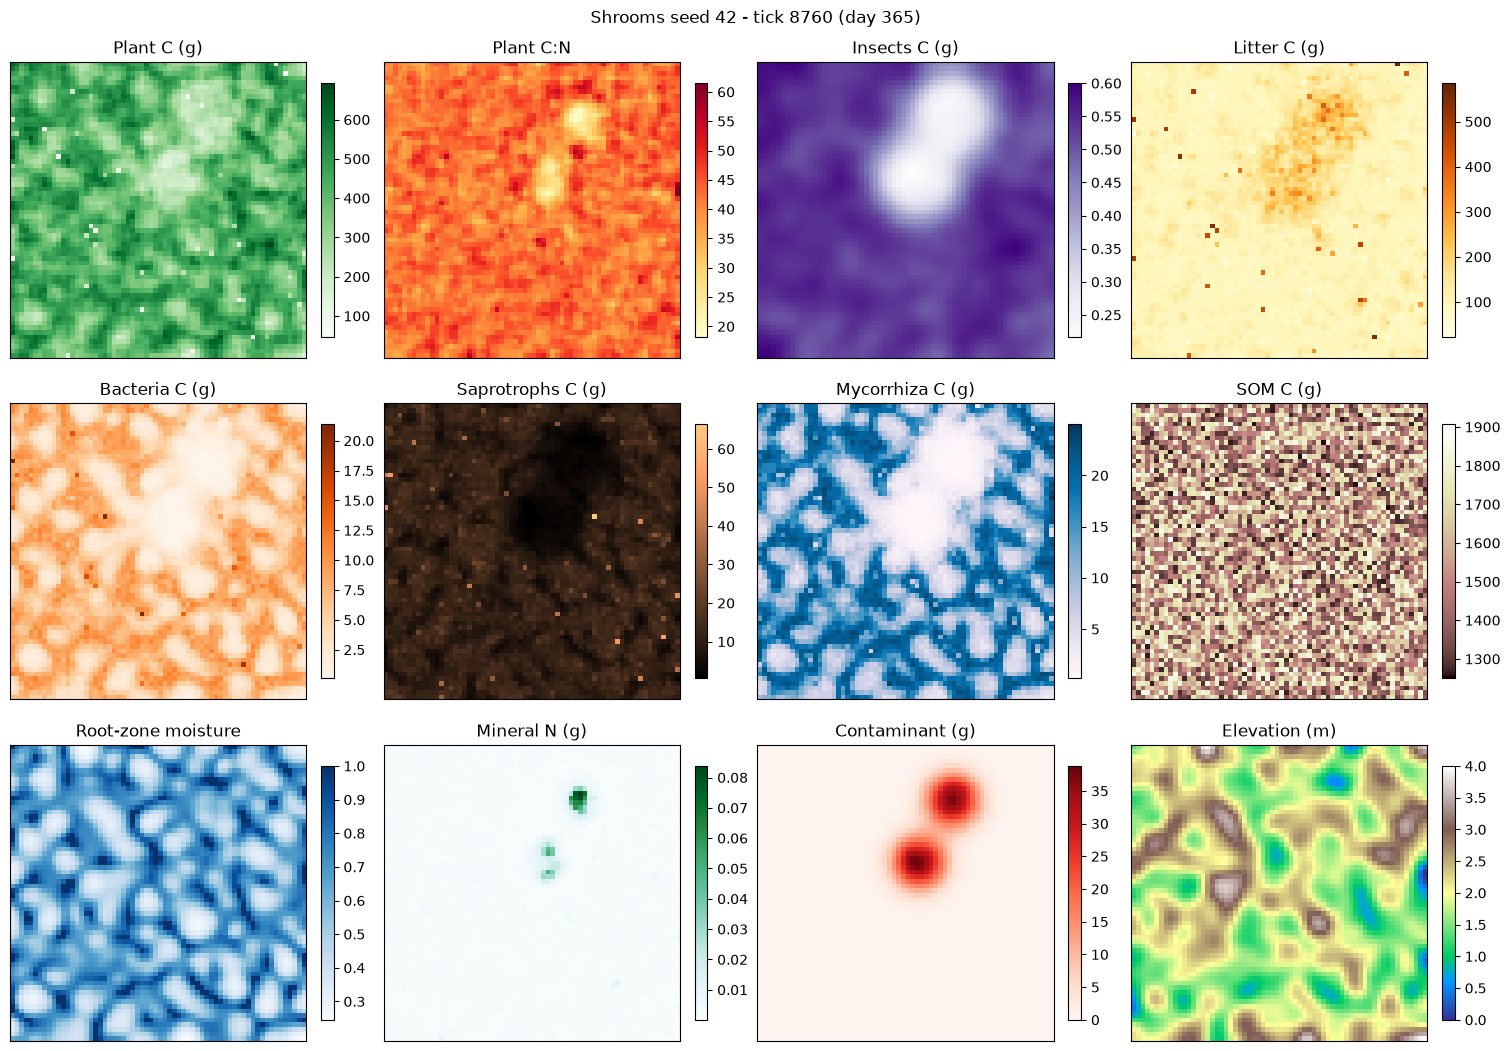

In [2]:
sim = Simulation(seed=42)
sim.run(TICKS_PER_YEAR)
grid_figure(sim);

Compare this with the Phase 0 grid, which was a near-uniform green. The heterogeneity here was not painted on; it emerges from local rules:

- **Moisture follows terrain.** Water flows downslope, so valleys stay wet and ridges dry out.
- **Plants, bacteria and mycorrhizae follow moisture.** They thrive where water lasts through summer.
- **The two contamination hotspots carry a brownfield signature.** Plants thin out, decomposers are suppressed so litter piles up, and nothing takes up nutrients, so mineral N accumulates. Insects avoid the hotspots only because they die faster there.

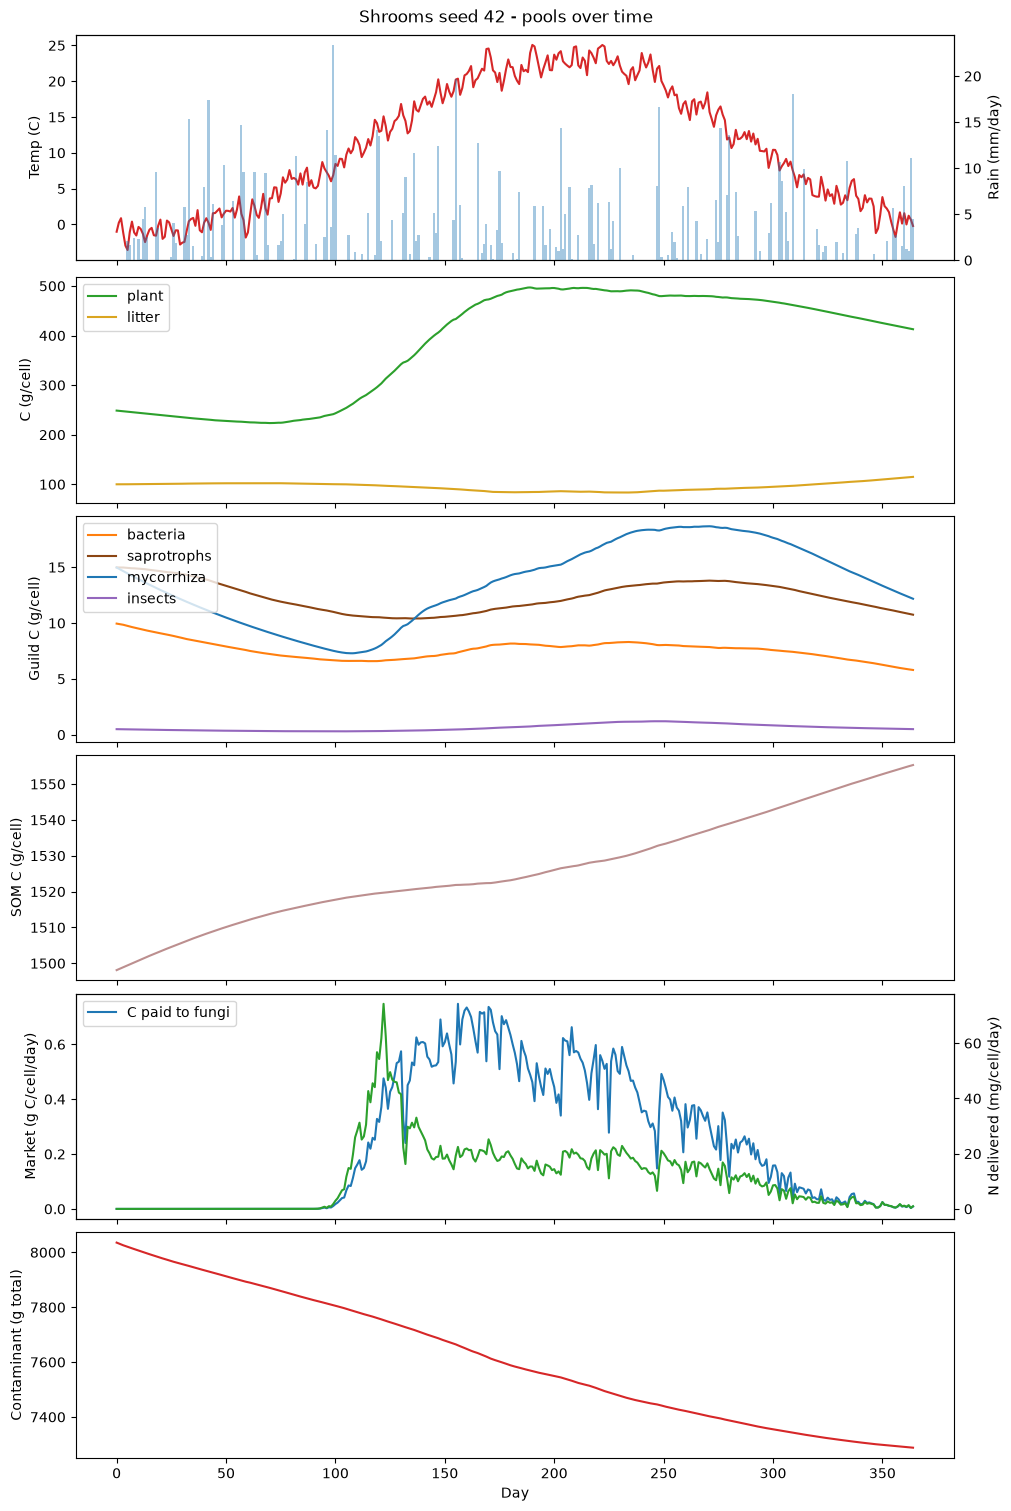

In [3]:
timeseries_figure(sim);

Every guild follows a seasonal cycle. Mycorrhizal trade runs only in the growing season: plants pay only while they photosynthesize, and only when they need nutrients.

## 2. The nitrogen budget

N enters by deposition and bacterial fixation and leaves by leaching and denitrification. Most of the action, though, is internal cycling.

In [4]:
n = sim.state.elevation.size
L = sim.ledger
print("Boundary N flows (g N per cell per year):")
for k, v in L.flows("n").items():
    print(f"  {k:>18}: {v / n:+7.2f}")
print("\nInternal N flows (g N per cell per year):")
for k, v in sorted(L.internal.items()):
    if k.startswith("n:"):
        print(f"  {k[2:]:>22}: {v / n:7.2f}")
print("\nWhere the N sits (g N per cell):")
s = sim.state
for name in POOLS:
    print(f"  {name:>12}: {s.pool(name).n.mean():7.2f}")
print(f"  {'mineral':>12}: {s.mineral_n.mean():7.3f}")

Boundary N flows (g N per cell per year):
            fixation:   +0.68
          deposition:   +0.73
            leaching:   -0.53
     denitrification:   -0.00

Internal N flows (g N per cell per year):
         fungal_foraging:    2.51
       fungal_som_mining:    6.72
          immobilization:    1.61
    mycorrhizal_delivery:    4.12
      net_mineralization:    0.79
             root_uptake:    1.56

Where the N sits (g N per cell):
         plant:    9.97
        litter:    1.83
           som:  128.70
      bacteria:    1.16
   saprotrophs:    1.07
    mycorrhiza:    1.68
       insects:    0.10
       mineral:   0.001


Some things to notice:

- **Nearly all the N sits in SOM.** The living guilds hold only a few g N/m² between them.
- **Mineral N is almost always near zero.** Every consumer grabs it as soon as it appears, so this is a strongly N-limited system.
- **Fungi mining SOM is the largest single N source for plants,** delivered through the mycorrhizal market. Root uptake of mineral N is small by comparison.

### Mineralize or immobilize?

A microbe that eats food with carbon-use efficiency CUE and builds a body with C:N ratio *r* needs N at a rate of CUE/*r* per unit of carbon eaten. If its food carries more N than that, the surplus is released as mineral N (**mineralization**). If it carries less, the microbe pulls N out of the soil (**immobilization**). The break-even food C:N is *r* / CUE: about 14 for bacteria and 22 for saprotrophs.

Leaf litter here has C:N ≈ 60, so decomposing litter *locks up* N. The N that plants eventually get comes back later, through microbial death, SOM, and bacteria eating SOM-derived dissolved organic matter (C:N ≈ 12). This is the single most important dynamic in the model, and getting it wrong caused the first tuning failure (see *What broke*).

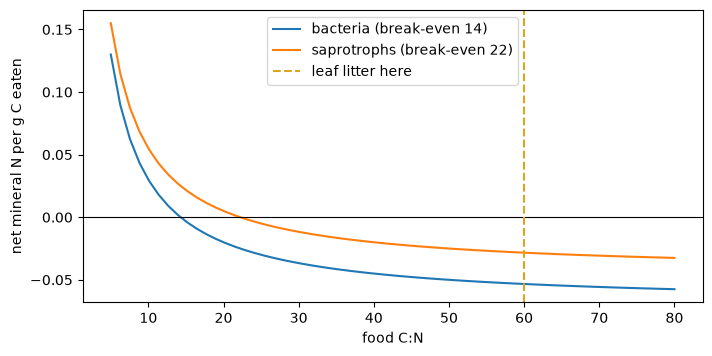

In [5]:
p = SimParams(world=WorldParams(width=4, height=4))
probe = Simulation(0, p)
ctx = TickContext(Weather(180, 12, 20.0, 600.0, 0.0), np.full((4, 4), 0.6), np.ones((4, 4)), probe.ledger)
ratios = np.linspace(5, 80, 60)
fig, ax = plt.subplots(figsize=(8, 3.8))
for name, m in (("bacteria", p.decomposers.bacteria), ("saprotrophs", p.decomposers.saprotrophs)):
    net = []
    for r in ratios:
        s = probe.state
        s.mineral_n = np.full((4, 4), 100.0)
        before = s.mineral_n.sum()
        grow_on(Pool.from_c(np.ones((4, 4)), m.cn, m.cp), Pool.from_c(np.ones((4, 4)), r, 30.0), m, s, ctx, name)
        net.append((s.mineral_n.sum() - before) / 16)
    ax.plot(ratios, net, label=f"{name} (break-even {m.cn / m.cue:.0f})")
ax.axhline(0, color="k", lw=0.8)
ax.axvline(60, color="goldenrod", ls="--", label="leaf litter here")
ax.set(xlabel="food C:N", ylabel="net mineral N per g C eaten")
ax.legend();

## 3. The mycorrhizal market (model A)

Here are the rules, in plain terms:

1. Fungi gather N and P, both from the mineral pools and by mining SOM.
2. They keep what their own bodies need, hold back a reserve, and offer the rest for sale.
3. Plants set a carbon budget proportional to how nutrient-starved they are.
4. Price rises when plant demand is high and fungal stock is thin.
5. Plants pay only for what is delivered.

None of these rules says "mutualism is good". If it is, it should show up in experiments, so here are two:

- **No fungi.** Start with zero mycorrhizal biomass.
- **N-rich world.** Deposition is 25× higher, as in heavily polluted regions.

My prediction for the N-rich world, written before running it: *well-fed plants will stop buying.* Each experiment runs for one year on a 32×32 world.

In [6]:
def experiment(label, **updates):
    base = SimParams(world=WorldParams(width=32, height=32))
    params = base.model_copy(update=updates) if updates else base
    s = Simulation(1, params)
    s.run(TICKS_PER_YEAR)
    n = s.state.elevation.size
    return {
        "label": label,
        "plant C": s.state.plant.c.mean(),
        "plant C:N": s.state.plant.c.sum() / s.state.plant.n.sum(),
        "plant C:P": s.state.plant.c.sum() / s.state.plant.p.sum(),
        "C paid to fungi": sum(s.history["trade_c"]) / n,
        "N bought": sum(s.history["trade_n"]) / n,
        "P bought (mg)": sum(s.history["trade_p"]) / n * 1000,
    }

base = SimParams()
no_fungi = base.mycorrhiza.model_copy(update={"guild": base.mycorrhiza.guild.model_copy(update={"initial_c": 0.0})})
n_rich = base.nutrients.model_copy(update={"n_deposition_per_day": base.nutrients.n_deposition_per_day * 25})
rows = [experiment("default"), experiment("no fungi", mycorrhiza=no_fungi), experiment("N-rich world", nutrients=n_rich)]
cols = list(rows[0])[1:]
print(f"{'':>13}" + "".join(f"{c:>16}" for c in cols))
for r in rows:
    print(f"{r['label']:>13}" + "".join(f"{r[c]:>16.1f}" for c in cols))

                      plant C       plant C:N       plant C:P C paid to fungi        N bought   P bought (mg)
      default           346.7            40.0           322.1            50.6             2.4           505.7
     no fungi           341.0            47.8           341.2             0.0             0.0             0.0
 N-rich world           383.4            25.9           346.2            47.9             4.4           566.0


**No fungi.** Plants lose their main N supply and end up clearly more N-starved (higher C:N), but only slightly smaller after one year. Nutrient stress acts through growth rate, so a biomass gap would compound over multiple years.

**N-rich world: the prediction was wrong.** Plants didn't stop buying. They spent about the same carbon and got *more* N for it. Breaking it down by quarter:

- N limitation is relieved (plant C:N drops to about its target of 30), so **P becomes the limiting nutrient** and plant C:P rises. P demand keeps the plant's carbon budget about the same size.
- The fungi are swimming in N (their store is 20–50× larger), so the market **price of N roughly halves**. Plants buy cheap N with the part of the budget they still allot to it.

Nitrogen deposition pushing ecosystems from N limitation toward P limitation is a documented real-world effect. Nothing coded it here; it fell out of demand-weighted budgets and stock-dependent prices. The lesson for the sandbox is to write the prediction down *before* running the experiment. That's the only way to notice the model knows something you didn't expect.

The Phase 6 comparison of models A, B and C will ask questions like this properly, on identical seeds and over several years.

## 4. A transect through a hotspot

This cuts through the most contaminated row of the end-of-year world.

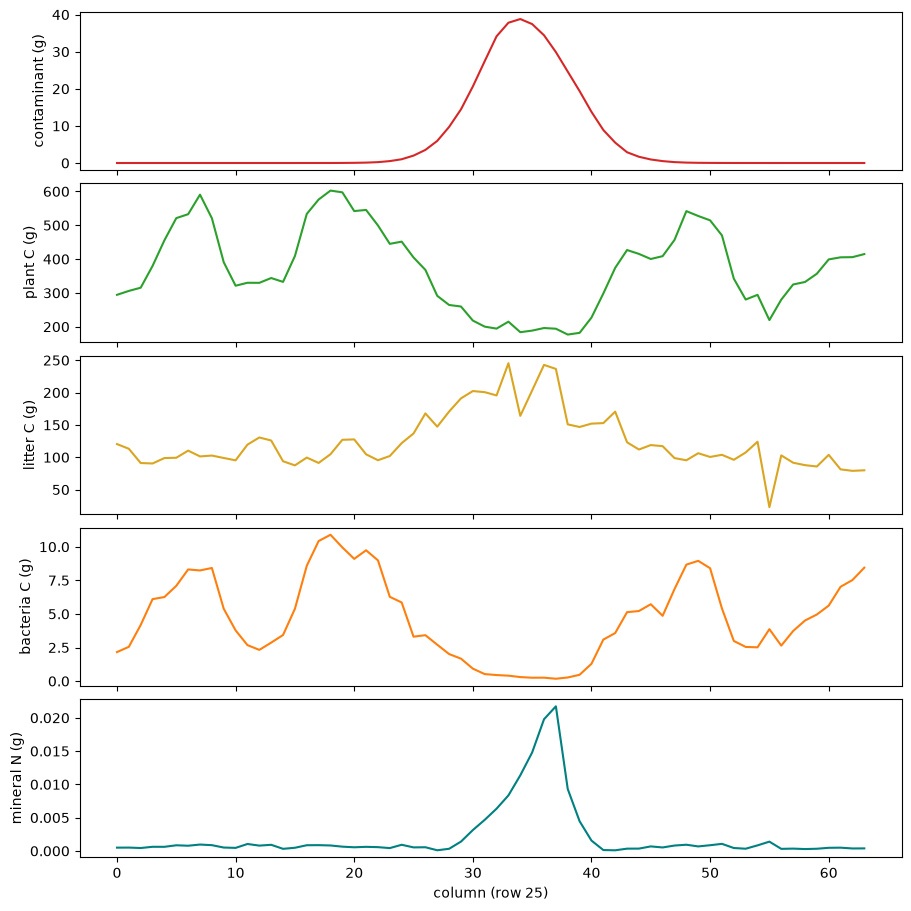

In [7]:
s = sim.state
row = int(np.unravel_index(s.contaminant.argmax(), s.shape)[0])
x = np.arange(s.shape[1])
fig, axes = plt.subplots(5, 1, figsize=(9, 9), sharex=True, constrained_layout=True)
for ax, (label, arr, color) in zip(axes, [
    ("contaminant (g)", s.contaminant, "tab:red"),
    ("plant C (g)", s.plant.c, "tab:green"),
    ("litter C (g)", s.litter.c, "goldenrod"),
    ("bacteria C (g)", s.bacteria.c, "tab:orange"),
    ("mineral N (g)", s.mineral_n, "teal"),
]):
    ax.plot(x, arr[row], color=color)
    ax.set_ylabel(label)
axes[-1].set_xlabel(f"column (row {row})");

Over the hotspot, toxicity suppresses both producers and decomposers. Litter accumulates, and so does mineral N, because nothing is taking it up. Degradation is slow, around 10% of the contaminant per year. That's deliberate: Phase 3's brownfield scenario is about the player speeding it up.

## 5. Terrain now matters

Phase 0 found corr(elevation, plant C) ≈ −0.03: terrain barely showed in plants. Lateral flow changes that.

In [8]:
e = s.elevation.ravel()
for label, arr in (("moisture", s.moisture()), ("plant C", s.plant.c), ("mycorrhiza C", s.mycorrhiza.c)):
    print(f"corr(elevation, {label:>12}) = {np.corrcoef(e, arr.ravel())[0, 1]:+.2f}")

corr(elevation,     moisture) = -0.70
corr(elevation,      plant C) = -0.44
corr(elevation, mycorrhiza C) = -0.45


## What broke (the tuning log)

Tuning *was* the Phase 1 skill. Here is what went wrong, in the order it happened.

1. **A nitrogen death spiral in month 3.** Microbes eating C:N 60 litter immobilized all the mineral N, then burned most of their food as overflow respiration and starved. SOM mineralization depended on bacteria, so N release stopped too, and everything collapsed. The fix was ecological, not numeric: faster SOM turnover (it's the real N source), slower microbial turnover, and mycorrhizal SOM mining.
2. **Insects ate most of the net production** (441 g C/cell/yr against a realistic ~50–100). Two fixes: insects absorb N far more efficiently than carbon (80% vs 35%), and strong density dependence keeps them near 0.5 g C/m², which is about what real grassland insects weigh.
3. **The contaminant leached to groundwater faster than it degraded.** Sorption went from 90% to 99.5%, typical of persistent organics like PAHs.
4. **Fungi sold their entire store** and then couldn't grow on what they earned. They now hold back a 30% reserve.
5. **Bacteria slowly lost to saprotrophs** on N-poor litter. SOM turnover now releases dissolved organic matter that bacteria eat. It's N-rich, so they mineralize it.
6. **Dispersal drained the grid edges.** An edge cell exported its full rate while receiving from only 3 neighbours. Mass was still conserved, but the flux was biased. This bug **existed in Phase 0 too** and went unnoticed until insects made it visible. Dispersal is now true diffusion (rate/4 per existing neighbour), with a regression test.
7. **The collapse gate measured spin-up, not stability.** Guilds started 3–4× above their equilibrium, so bacteria "fell" to 15% of their start in year 1 while being perfectly flat from year 1 to year 3. Initial pools now sit near the equilibrium found by multi-year runs.

## Known issues

- **Speed.** About 350 ticks/s, 10× slower than Phase 0, because the tick is bound by hundreds of small numpy operations. Phase 4 needs ≥1,000 ticks/s, which calls for Numba.
- **Very tight N limitation.** Mineral N sits near zero all year. That's defensible, but it makes N leaching negligible and may be too extreme.
- **SOM still creeps up,** about 40 g C/cell/yr. Its equilibrium is decades out, so datasets will need a spin-up period.
- **Simplifications.** Solutes aren't layered, microbes don't disperse, insects wander randomly instead of seeking food, SOM is a single pool, and P essentially never leaches.

## Try it

1. Set `contamination.sorbed_fraction = 0.9` and watch a plume creep downslope.
2. Set `decomposers.som_turnover_per_day` back to 0.00008 and reproduce the death spiral. Which guild goes first?
3. Give plants perfect nutrition (`target_cn = 1000`). What happens to the market and to fungal biomass?